# Task 3: Event Impact Modeling

## Forecasting Financial Inclusion in Ethiopia

This notebook models how financial-sector events—including product launches, policy reforms, infrastructure investments, market entries, and regulatory changes—may influence financial inclusion indicators in Ethiopia.

### Objectives

1. Load and validate the enriched financial inclusion dataset.
2. Join impact-link records with their parent events.
3. Summarize which events affect which indicators.
4. Build an event–indicator association matrix.
5. Model delayed event effects using documented implementation lags.
6. Compare modeled event effects with available historical observations.
7. Document assumptions, validation results, and uncertainty.

Events remain pillar-neutral in the unified dataset. Their potential effects on Access, Usage, Affordability, Gender, and other dimensions are represented through the associated `impact_link` records.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["axes.grid"] = True

In [2]:
def validate_required_columns(
    dataframe,
    required_columns,
    dataframe_name="DataFrame"
):
    """
    Confirm that a DataFrame contains all required columns.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        DataFrame to validate.
    required_columns : list
        Columns required for the analysis.
    dataframe_name : str
        Descriptive name used in error messages.

    Raises
    ------
    TypeError
        If dataframe is not a pandas DataFrame.
    ValueError
        If required columns are missing.
    """
    if not isinstance(dataframe, pd.DataFrame):
        raise TypeError(
            f"{dataframe_name} must be a pandas DataFrame."
        )

    missing_columns = [
        column
        for column in required_columns
        if column not in dataframe.columns
    ]

    if missing_columns:
        raise ValueError(
            f"{dataframe_name} is missing required columns: "
            f"{missing_columns}"
        )

    return True

In [3]:
current_path = Path.cwd()

if current_path.name == "notebooks":
    project_root = current_path.parent
else:
    project_root = current_path

data_path = (
    project_root
    / "data"
    / "processed"
    / "ethiopia_fi_enriched.csv"
)

figures_path = (
    project_root
    / "reports"
    / "figures"
)

models_path = project_root / "models"

figures_path.mkdir(parents=True, exist_ok=True)
models_path.mkdir(parents=True, exist_ok=True)

print("Project root:", project_root)
print("Dataset exists:", data_path.exists())
print("Figures directory:", figures_path)
print("Models directory:", models_path)


Project root: c:\Users\gebre\OneDrive\Documents\Programming\KIAM 10 academy\Week 11\ethiopia-fi-forecast
Dataset exists: True
Figures directory: c:\Users\gebre\OneDrive\Documents\Programming\KIAM 10 academy\Week 11\ethiopia-fi-forecast\reports\figures
Models directory: c:\Users\gebre\OneDrive\Documents\Programming\KIAM 10 academy\Week 11\ethiopia-fi-forecast\models


In [4]:
if not data_path.exists():
    raise FileNotFoundError(
        f"Enriched dataset was not found at: {data_path}"
    )

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (58, 35)


,category,collected_by,collection_date,comparable_country,confidence,evidence_basis,fiscal_year,gender,impact_direction,impact_estimate,impact_magnitude,indicator,indicator_code,indicator_direction,lag_months,location,notes,observation_date,original_text,parent_id,period_end,period_start,pillar,record_id,record_type,region,related_indicator,relationship_type,source_name,source_type,source_url,unit,value_numeric,value_text,value_type
0,NaN,Bilen M. Gebremariam,2025-01-20,NaN,high,NaN,2014,all,NaN,NaN,NaN,Account Ownership Rate,ACC_OWNERSHIP,higher_better,NaN,national,NaN,2014-12-31,Baseline year,NaN,NaN,NaN,ACCESS,REC_0001,observation,NaN,NaN,NaN,Global Findex 2014,survey,https://www.worldbank.org/en/publication/globa...,%,22.0,NaN,percentage
1,NaN,Bilen M. Gebremariam,2025-01-20,NaN,high,NaN,2017,all,NaN,NaN,NaN,Account Ownership Rate,ACC_OWNERSHIP,higher_better,NaN,national,NaN,2017-12-31,NaN,NaN,NaN,NaN,ACCESS,REC_0002,observation,NaN,NaN,NaN,Global Findex 2017,survey,https://www.worldbank.org/en/publication/globa...,%,35.0,NaN,percentage
2,NaN,Bilen M. Gebremariam,2025-01-20,NaN,high,NaN,2021,all,NaN,NaN,NaN,Account Ownership Rate,ACC_OWNERSHIP,higher_better,NaN,national,NaN,2021-12-31,NaN,NaN,NaN,NaN,ACCESS,REC_0003,observation,NaN,NaN,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,%,46.0,NaN,percentage
3,NaN,Bilen M. Gebremariam,2025-01-20,NaN,high,NaN,2021,male,NaN,NaN,NaN,Account Ownership Rate,ACC_OWNERSHIP,higher_better,NaN,national,NaN,2021-12-31,Gender disaggregated,NaN,NaN,NaN,ACCESS,REC_0004,observation,NaN,NaN,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,%,56.0,NaN,percentage
4,NaN,Bilen M. Gebremariam,2025-01-20,NaN,high,NaN,2021,female,NaN,NaN,NaN,Account Ownership Rate,ACC_OWNERSHIP,higher_better,NaN,national,NaN,2021-12-31,Gender disaggregated,NaN,NaN,NaN,ACCESS,REC_0005,observation,NaN,NaN,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,%,36.0,NaN,percentage


In [5]:
required_columns = [
    "record_id",
    "parent_id",
    "record_type",
    "category",
    "pillar",
    "indicator",
    "indicator_code",
    "related_indicator",
    "impact_direction",
    "impact_magnitude",
    "lag_months",
    "confidence",
    "evidence_basis",
    "period_start",
    "observation_date",
    "value_numeric"
]

validate_required_columns(
    df,
    required_columns,
    dataframe_name="Enriched financial inclusion dataset"
)

print("Task 3 required-column validation passed.")

Task 3 required-column validation passed.


In [6]:
date_columns = [
    "period_start",
    "period_end",
    "observation_date",
    "collection_date"
]

for column in date_columns:
    if column in df.columns:
        df[column] = pd.to_datetime(
            df[column],
            format="mixed",
            errors="coerce"
        )

numeric_columns = [
    "value_numeric",
    "impact_magnitude",
    "lag_months"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

print("Date and numeric conversion completed.")

Date and numeric conversion completed.


In [7]:
events = df[
    df["record_type"] == "event"
].copy()

impact_links = df[
    df["record_type"] == "impact_link"
].copy()

observations = df[
    df["record_type"] == "observation"
].copy()

targets = df[
    df["record_type"] == "target"
].copy()

record_summary = pd.DataFrame({
    "record_type": [
        "events",
        "impact_links",
        "observations",
        "targets"
    ],
    "record_count": [
        len(events),
        len(impact_links),
        len(observations),
        len(targets)
    ]
})

record_summary

,record_type,record_count
0,events,10
1,impact_links,14
2,observations,31
3,targets,3


In [8]:
event_ids = set(events["record_id"].dropna())
parent_ids = set(impact_links["parent_id"].dropna())

unmatched_parent_ids = sorted(
    parent_ids - event_ids
)

print(
    "Impact links with unmatched parent events:",
    len(unmatched_parent_ids)
)

if unmatched_parent_ids:
    display(
        impact_links[
            impact_links["parent_id"].isin(
                unmatched_parent_ids
            )
        ]
    )
else:
    print(
        "All impact links are connected to valid events."
    )

Impact links with unmatched parent events: 0
All impact links are connected to valid events.


## 1. Event and Impact-Link Preparation

The unified schema stores events independently from the financial inclusion pillars. An event may influence multiple indicators and pillars, so the event records are joined to the `impact_link` records through `parent_id`.

Each impact link provides:

- the affected indicator,
- the affected pillar,
- the expected direction,
- the estimated magnitude,
- the implementation lag,
- the confidence level,
- and the evidence supporting the relationship.

In [9]:
event_details = events[
    [
        "record_id",
        "indicator",
        "category",
        "period_start",
        "original_text",
        "source_name",
        "source_url"
    ]
].rename(
    columns={
        "record_id": "event_id",
        "indicator": "event_name",
        "category": "event_category",
        "period_start": "event_date",
        "original_text": "event_description",
        "source_name": "event_source",
        "source_url": "event_source_url"
    }
)

event_impact_data = impact_links.merge(
    event_details,
    left_on="parent_id",
    right_on="event_id",
    how="left",
    validate="many_to_one"
)

print(
    "Joined event-impact records:",
    len(event_impact_data)
)

event_impact_data[
    [
        "parent_id",
        "event_name",
        "event_category",
        "pillar",
        "related_indicator",
        "impact_direction",
        "impact_magnitude",
        "lag_months",
        "confidence"
    ]
].sort_values(
    [
        "event_name",
        "related_indicator"
    ]
)

Joined event-impact records: 14


,parent_id,event_name,event_category,pillar,related_indicator,impact_direction,impact_magnitude,lag_months,confidence
12,EVT_0008,EthioPay Instant Payment System Launch,infrastructure,USAGE,USG_P2P_COUNT,increase,NaN,6.0,medium
7,EVT_0004,Fayda Digital ID Program Rollout,infrastructure,ACCESS,ACC_OWNERSHIP,increase,NaN,24.0,medium
8,EVT_0004,Fayda Digital ID Program Rollout,infrastructure,GENDER,GEN_GAP_ACC,decrease,NaN,24.0,medium
9,EVT_0005,Foreign Exchange Liberalization,policy,AFFORDABILITY,AFF_DATA_INCOME,increase,NaN,3.0,high
10,EVT_0007,M-Pesa EthSwitch Integration,partnership,USAGE,USG_MPESA_ACTIVE,increase,NaN,3.0,medium
11,EVT_0007,M-Pesa EthSwitch Integration,partnership,USAGE,USG_P2P_COUNT,increase,NaN,3.0,medium
6,EVT_0003,M-Pesa Ethiopia Launch,product_launch,ACCESS,ACC_MM_ACCOUNT,increase,NaN,6.0,medium
5,EVT_0003,M-Pesa Ethiopia Launch,product_launch,USAGE,USG_MPESA_USERS,increase,NaN,3.0,high
3,EVT_0002,Safaricom Ethiopia Commercial Launch,market_entry,ACCESS,ACC_4G_COV,increase,NaN,12.0,medium
4,EVT_0002,Safaricom Ethiopia Commercial Launch,market_entry,AFFORDABILITY,AFF_DATA_INCOME,decrease,NaN,12.0,medium


In [10]:
direction_scores = {
    "increase": 1,
    "decrease": -1,
    "neutral": 0
}

confidence_weights = {
    "high": 1.00,
    "medium": 0.75,
    "low": 0.50
}

event_impact_data["direction_score"] = (
    event_impact_data["impact_direction"]
    .str.lower()
    .map(direction_scores)
)

event_impact_data["confidence_weight"] = (
    event_impact_data["confidence"]
    .str.lower()
    .map(confidence_weights)
    .fillna(0.50)
)

event_impact_data["signed_magnitude"] = (
    event_impact_data["impact_magnitude"]
    * event_impact_data["direction_score"]
)

event_impact_data["weighted_effect"] = (
    event_impact_data["signed_magnitude"]
    * event_impact_data["confidence_weight"]
)

event_impact_data[
    [
        "event_name",
        "related_indicator",
        "impact_direction",
        "impact_magnitude",
        "confidence",
        "signed_magnitude",
        "weighted_effect"
    ]
]

,event_name,related_indicator,impact_direction,impact_magnitude,confidence,signed_magnitude,weighted_effect
0,Telebirr Launch,ACC_OWNERSHIP,increase,NaN,medium,NaN,NaN
1,Telebirr Launch,USG_TELEBIRR_USERS,increase,NaN,high,NaN,NaN
2,Telebirr Launch,USG_P2P_COUNT,increase,NaN,medium,NaN,NaN
3,Safaricom Ethiopia Commercial Launch,ACC_4G_COV,increase,NaN,medium,NaN,NaN
4,Safaricom Ethiopia Commercial Launch,AFF_DATA_INCOME,decrease,NaN,medium,NaN,NaN
5,M-Pesa Ethiopia Launch,USG_MPESA_USERS,increase,NaN,high,NaN,NaN
6,M-Pesa Ethiopia Launch,ACC_MM_ACCOUNT,increase,NaN,medium,NaN,NaN
7,Fayda Digital ID Program Rollout,ACC_OWNERSHIP,increase,NaN,medium,NaN,NaN
8,Fayda Digital ID Program Rollout,GEN_GAP_ACC,decrease,NaN,medium,NaN,NaN
9,Foreign Exchange Liberalization,AFF_DATA_INCOME,increase,NaN,high,NaN,NaN


In [11]:
association_summary = event_impact_data[
    [
        "event_id",
        "event_name",
        "event_category",
        "event_date",
        "pillar",
        "related_indicator",
        "impact_direction",
        "impact_magnitude",
        "lag_months",
        "confidence",
        "weighted_effect",
        "evidence_basis"
    ]
].sort_values(
    [
        "event_date",
        "event_name",
        "related_indicator"
    ],
    na_position="last"
)

association_summary

,event_id,event_name,event_category,event_date,pillar,related_indicator,impact_direction,impact_magnitude,lag_months,confidence,weighted_effect,evidence_basis
12,EVT_0008,EthioPay Instant Payment System Launch,infrastructure,NaT,USAGE,USG_P2P_COUNT,increase,NaN,6.0,medium,NaN,literature
7,EVT_0004,Fayda Digital ID Program Rollout,infrastructure,NaT,ACCESS,ACC_OWNERSHIP,increase,NaN,24.0,medium,NaN,literature
8,EVT_0004,Fayda Digital ID Program Rollout,infrastructure,NaT,GENDER,GEN_GAP_ACC,decrease,NaN,24.0,medium,NaN,literature
9,EVT_0005,Foreign Exchange Liberalization,policy,NaT,AFFORDABILITY,AFF_DATA_INCOME,increase,NaN,3.0,high,NaN,empirical
10,EVT_0007,M-Pesa EthSwitch Integration,partnership,NaT,USAGE,USG_MPESA_ACTIVE,increase,NaN,3.0,medium,NaN,literature
11,EVT_0007,M-Pesa EthSwitch Integration,partnership,NaT,USAGE,USG_P2P_COUNT,increase,NaN,3.0,medium,NaN,literature
6,EVT_0003,M-Pesa Ethiopia Launch,product_launch,NaT,ACCESS,ACC_MM_ACCOUNT,increase,NaN,6.0,medium,NaN,theoretical
5,EVT_0003,M-Pesa Ethiopia Launch,product_launch,NaT,USAGE,USG_MPESA_USERS,increase,NaN,3.0,high,NaN,empirical
3,EVT_0002,Safaricom Ethiopia Commercial Launch,market_entry,NaT,ACCESS,ACC_4G_COV,increase,NaN,12.0,medium,NaN,empirical
4,EVT_0002,Safaricom Ethiopia Commercial Launch,market_entry,NaT,AFFORDABILITY,AFF_DATA_INCOME,decrease,NaN,12.0,medium,NaN,literature


In [12]:
association_matrix = event_impact_data.pivot_table(
    index="event_name",
    columns="related_indicator",
    values="weighted_effect",
    aggfunc="sum",
    fill_value=0
)

association_matrix

related_indicator,ACC_4G_COV,ACC_MM_ACCOUNT,ACC_OWNERSHIP,AFF_DATA_INCOME,GEN_GAP_ACC,USG_MPESA_ACTIVE,USG_MPESA_USERS,USG_P2P_COUNT,USG_TELEBIRR_USERS
event_name,,,,,,,,,
EthioPay Instant Payment System Launch,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Fayda Digital ID Program Rollout,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Foreign Exchange Liberalization,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
M-Pesa EthSwitch Integration,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
M-Pesa Ethiopia Launch,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Safaricom Ethiopia Commercial Launch,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Safaricom Ethiopia Price Increase,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Telebirr Launch,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
association_matrix_path = (
    models_path
    / "event_indicator_association_matrix.csv"
)

association_summary_path = (
    models_path
    / "event_indicator_association_summary.csv"
)

association_matrix.to_csv(
    association_matrix_path
)

association_summary.to_csv(
    association_summary_path,
    index=False
)

print("Association matrix saved to:")
print(association_matrix_path)

print("\nAssociation summary saved to:")
print(association_summary_path)

Association matrix saved to:
c:\Users\gebre\OneDrive\Documents\Programming\KIAM 10 academy\Week 11\ethiopia-fi-forecast\models\event_indicator_association_matrix.csv

Association summary saved to:
c:\Users\gebre\OneDrive\Documents\Programming\KIAM 10 academy\Week 11\ethiopia-fi-forecast\models\event_indicator_association_summary.csv


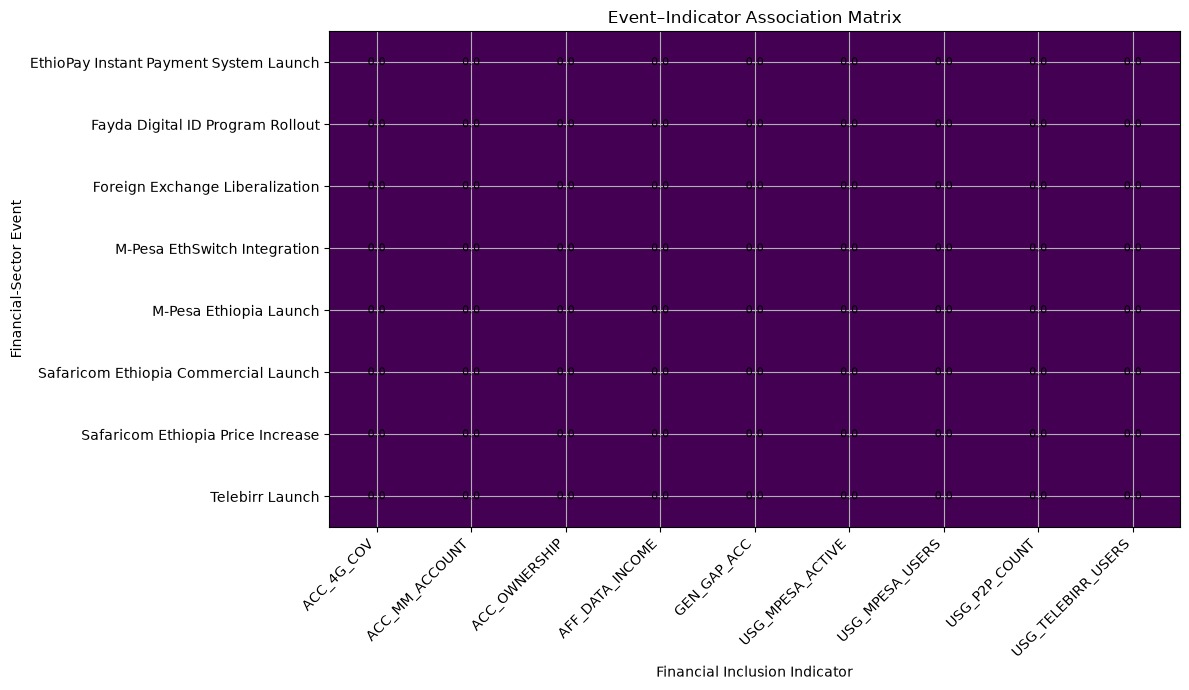

Figure saved to:
c:\Users\gebre\OneDrive\Documents\Programming\KIAM 10 academy\Week 11\ethiopia-fi-forecast\reports\figures\event_indicator_association_matrix.png


In [14]:
fig, ax = plt.subplots(
    figsize=(
        max(12, len(association_matrix.columns) * 1.2),
        max(7, len(association_matrix.index) * 0.65)
    )
)

heatmap = ax.imshow(
    association_matrix.values,
    aspect="auto"
)

ax.set_xticks(
    range(len(association_matrix.columns))
)

ax.set_xticklabels(
    association_matrix.columns,
    rotation=45,
    horizontalalignment="right"
)

ax.set_yticks(
    range(len(association_matrix.index))
)

ax.set_yticklabels(
    association_matrix.index
)

ax.set_title(
    "Event–Indicator Association Matrix"
)

ax.set_xlabel(
    "Financial Inclusion Indicator"
)

ax.set_ylabel(
    "Financial-Sector Event"
)

for row_index in range(
    len(association_matrix.index)
):
    for column_index in range(
        len(association_matrix.columns)
    ):
        value = association_matrix.iloc[
            row_index,
            column_index
        ]

        ax.text(
            column_index,
            row_index,
            f"{value:.1f}",
            horizontalalignment="center",
            verticalalignment="center",
            fontsize=8
        )

figure_path = (
    figures_path
    / "event_indicator_association_matrix.png"
)

plt.tight_layout()
plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("Figure saved to:")
print(figure_path)

### Association Matrix Interpretation

The event–indicator association matrix summarizes which financial-sector events are expected to influence each financial inclusion indicator and the estimated strength and direction of those relationships.

Positive values represent expected increases, while negative values represent expected decreases. The values are based on the documented impact magnitude and are adjusted using the confidence classification of each impact link.

A value of zero does not prove that an event has no effect. It only indicates that no explicit relationship is documented in the available impact-link dataset.

The matrix is a structured modeling input rather than a causal estimate. It will be used to construct event-adjusted scenarios and to compare documented expectations against observed historical changes.

In [15]:
commit_1_checks = {
    "dataset_loaded": not df.empty,
    "events_available": len(events) == 10,
    "impact_links_available": len(impact_links) == 14,
    "all_parent_links_valid": (
        len(unmatched_parent_ids) == 0
    ),
    "joined_records_complete": (
        len(event_impact_data) == len(impact_links)
    ),
    "association_matrix_created": (
        not association_matrix.empty
    ),
    "association_matrix_saved": (
        association_matrix_path.exists()
    ),
    "association_figure_saved": (
        figure_path.exists()
    )
}

commit_1_validation = pd.DataFrame(
    commit_1_checks.items(),
    columns=[
        "validation_check",
        "passed"
    ]
)

commit_1_validation

,validation_check,passed
0,dataset_loaded,True
1,events_available,True
2,impact_links_available,True
3,all_parent_links_valid,True
4,joined_records_complete,True
5,association_matrix_created,True
6,association_matrix_saved,True
7,association_figure_saved,True


In [16]:
if not commit_1_validation["passed"].all():
    failed_checks = commit_1_validation[
        ~commit_1_validation["passed"]
    ]

    display(failed_checks)

    raise ValueError(
        "Commit 1 validation failed."
    )

print(
    "All Commit 1 validation checks passed."
)

All Commit 1 validation checks passed.
